# Chicken Threat Detector Model v4

## Install dependencies

Run once per runtime. Restart the runtime if Colab asks for it, then continue from the next cell.


In [2]:
%pip install -q --upgrade ultralytics pyyaml matplotlib tqdm opencv-python-headless "numpy<2.3" "pandas>=2.2,<2.4" "pillow>=10.4.0,<11.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 109.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 28.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 82.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 103.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account al

## Runtime setup

In [3]:
import os
import random
import shutil
import sys
from collections import Counter
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image
from tqdm.auto import tqdm

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in str(get_ipython())
USE_GOOGLE_DRIVE = False

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    os.environ.setdefault(
        "CHICKEN_THREAT_WORKDIR",
        "/content/drive/MyDrive/chicken_threat_detector_v4_model"
    )
elif IN_COLAB:
    os.environ.setdefault(
        "CHICKEN_THREAT_WORKDIR",
        "/content/chicken_threat_detector_v4_model"
    )

WORK_DIR = Path(
    os.getenv("CHICKEN_THREAT_WORKDIR", "data/chicken_threat_detector_v4_model")
).resolve()

IMPORT_ROOT = WORK_DIR / "imported_dataset"
RUNS_ROOT = WORK_DIR / "runs"
EXPORT_ROOT = WORK_DIR / "exports"

for directory in (WORK_DIR, IMPORT_ROOT, RUNS_ROOT, EXPORT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "valid", "test")
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CANONICAL_NAMES = [
    "chicken",
    "other_poultry",
    "rodent",
    "fox",
    "cat",
    "dog",
    "bird_of_prey",
    "other_bird",
    "person",
]

print(f"IN_COLAB={IN_COLAB}")
print(f"WORK_DIR={WORK_DIR}")

IN_COLAB=True
WORK_DIR=/content/chicken_threat_detector_v4_model


## Upload and unpack dataset ZIP

Use the ZIP exported by the data notebook.

In [4]:
def clean_dir(path: Path) -> None:
    path = path.resolve()
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def copy_dataset_folder(source: Path, destination: Path) -> None:
    """
    Copies a read-only dataset folder, for example from /kaggle/input,
    into a writable working directory.
    """
    source = source.resolve()
    destination = destination.resolve()

    if not source.exists():
        raise FileNotFoundError(f"Dataset source folder not found: {source}")

    if not source.is_dir():
        raise NotADirectoryError(f"Dataset source is not a directory: {source}")

    clean_dir(destination)

    for item in source.iterdir():
        target = destination / item.name

        if item.is_dir():
            shutil.copytree(item, target)
        else:
            shutil.copy2(item, target)


def find_dataset_root(root: Path) -> Path:
    """
    Finds the folder containing data.yaml and train/valid image folders.
    Supports datasets where data.yaml is either directly in root
    or nested inside one subfolder.
    """
    root = root.resolve()

    candidates = [root]

    for data_yaml in root.rglob("data.yaml"):
        candidates.append(data_yaml.parent)

    for dataset_root in candidates:
        if (dataset_root / "data.yaml").exists():
            has_train = (dataset_root / "train" / "images").exists()
            has_valid = (dataset_root / "valid" / "images").exists()

            if has_train and has_valid:
                return dataset_root.resolve()

    raise FileNotFoundError(
        f"Could not find a YOLO data.yaml with train/valid folders under {root}"
    )


def rewrite_data_yaml(dataset_root: Path) -> Path:
    """
    Rewrites data.yaml so Ultralytics can resolve all split paths correctly.
    This must happen in a writable copy, not directly inside /kaggle/input.
    """
    data_yaml = dataset_root / "data.yaml"

    data = yaml.safe_load(data_yaml.read_text(encoding="utf-8")) or {}

    data["path"] = str(dataset_root.resolve())
    data.setdefault("train", "train/images")
    data.setdefault("val", "valid/images")
    data.setdefault("test", "test/images")

    names = data.get("names", CANONICAL_NAMES)

    # Supports both list-style and dict-style YOLO names.
    if isinstance(names, dict):
        data["nc"] = len(names)
    else:
        data["nc"] = len(names)

    data_yaml.write_text(
        yaml.safe_dump(data, sort_keys=False),
        encoding="utf-8"
    )

    return data_yaml

In [5]:
DATASET_SOURCE_PATH = Path("/kaggle/input/datasets/dumdart/chicken-thread-dataset-v4")

source_path = Path(DATASET_SOURCE_PATH).resolve()
copy_dataset_folder(source_path, IMPORT_ROOT)

DATASET_ROOT = find_dataset_root(IMPORT_ROOT)
DATA_YAML = rewrite_data_yaml(DATASET_ROOT)
print(f"Dataset root: {DATASET_ROOT}")
print(f"data.yaml: {DATA_YAML}")

Dataset root: /content/chicken_threat_detector_v4_model/imported_dataset
data.yaml: /content/chicken_threat_detector_v4_model/imported_dataset/data.yaml


## Dataset validation and class balance

In [6]:
def load_class_names(dataset_root: Path) -> list[str]:
    data = yaml.safe_load((dataset_root / "data.yaml").read_text(encoding="utf-8"))
    names = data.get("names")
    if isinstance(names, dict):
        return [str(names[key]) for key in sorted(names, key=lambda key: int(key))]
    if isinstance(names, list):
        return [str(name) for name in names]
    raise ValueError("data.yaml has unsupported names format")


def image_files(image_dir: Path) -> list[Path]:
    if not image_dir.exists():
        return []
    return sorted(path for path in image_dir.iterdir() if path.suffix.lower() in IMAGE_SUFFIXES)


def clip_yolo_box(box: Iterable[float]) -> tuple[float, float, float, float] | None:
    x_center, y_center, width, height = [float(value) for value in box]
    if width <= 0 or height <= 0:
        return None
    x_min = max(0.0, x_center - width / 2)
    y_min = max(0.0, y_center - height / 2)
    x_max = min(1.0, x_center + width / 2)
    y_max = min(1.0, y_center + height / 2)
    width = x_max - x_min
    height = y_max - y_min
    if width <= 0 or height <= 0:
        return None
    return ((x_min + x_max) / 2, (y_min + y_max) / 2, width, height)


def parse_yolo_line(line: str) -> tuple[int, tuple[float, float, float, float]] | None:
    parts = line.split()
    if len(parts) != 5:
        return None
    try:
        class_id = int(float(parts[0]))
        coords = [float(value) for value in parts[1:]]
    except ValueError:
        return None
    box = clip_yolo_box(coords)
    if box is None:
        return None
    return class_id, box


def summarize_dataset(dataset_root: Path) -> pd.DataFrame:
    names = load_class_names(dataset_root)
    rows = []
    for split in SPLITS:
        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"
        counts = Counter()
        invalid = 0
        missing = 0
        empty = 0
        for image_path in image_files(image_dir):
            label_path = label_dir / f"{image_path.stem}.txt"
            if not label_path.exists():
                missing += 1
                continue
            text = label_path.read_text(encoding="utf-8").strip()
            if not text:
                empty += 1
                continue
            for line in text.splitlines():
                parsed = parse_yolo_line(line)
                if parsed is None:
                    invalid += 1
                    continue
                class_id, _ = parsed
                label = names[class_id] if 0 <= class_id < len(names) else f"unknown:{class_id}"
                counts[label] += 1
        for name in names:
            rows.append({"split": split, "class": name, "objects": counts[name]})
        rows.append({"split": split, "class": "__images__", "objects": len(image_files(image_dir))})
        rows.append({"split": split, "class": "__missing_label_files__", "objects": missing})
        rows.append({"split": split, "class": "__empty_label_files__", "objects": empty})
        rows.append({"split": split, "class": "__invalid_labels__", "objects": invalid})
    return pd.DataFrame(rows)


def validate_dataset(dataset_root: Path) -> list[str]:
    errors = []
    names = load_class_names(dataset_root)
    if names != CANONICAL_NAMES:
        errors.append(f"Class names differ from expected canonical names: {names}")
    for split in SPLITS:
        image_dir = dataset_root / split / "images"
        label_dir = dataset_root / split / "labels"
        if not image_dir.exists():
            errors.append(f"Missing image directory: {image_dir}")
        if not label_dir.exists():
            errors.append(f"Missing label directory: {label_dir}")
        image_stems = {path.stem for path in image_files(image_dir)}
        label_stems = {path.stem for path in label_dir.glob("*.txt")} if label_dir.exists() else set()
        if image_stems - label_stems:
            errors.append(f"{split}: {len(image_stems - label_stems)} missing label files")
        if label_stems - image_stems:
            errors.append(f"{split}: {len(label_stems - image_stems)} orphan label files")
        for label_path in sorted(label_dir.glob("*.txt")) if label_dir.exists() else []:
            for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
                if not line.strip():
                    continue
                parsed = parse_yolo_line(line)
                if parsed is None:
                    errors.append(f"{label_path}:{line_number}: invalid label row")
                    continue
                class_id, box = parsed
                if not 0 <= class_id < len(names):
                    errors.append(f"{label_path}:{line_number}: class id out of range")
                if any(value < 0 or value > 1 for value in box):
                    errors.append(f"{label_path}:{line_number}: box outside 0..1")
    return errors


summary_df = summarize_dataset(DATASET_ROOT)
display(summary_df.pivot(index="class", columns="split", values="objects").fillna(0).astype(int))

validation_errors = validate_dataset(DATASET_ROOT)
if validation_errors:
    print("Validation failed:")
    for error in validation_errors[:100]:
        print(" -", error)
    raise RuntimeError(f"Dataset validation failed with {len(validation_errors)} errors.")
print("Validation passed.")


split,test,train,valid
class,,,
__empty_label_files__,0,0,0
__images__,832,4547,788
__invalid_labels__,0,0,0
__missing_label_files__,0,0,0
bird_of_prey,82,358,72
cat,160,1100,160
chicken,159,713,135
dog,200,1200,200
fox,220,1200,220


Validation passed.


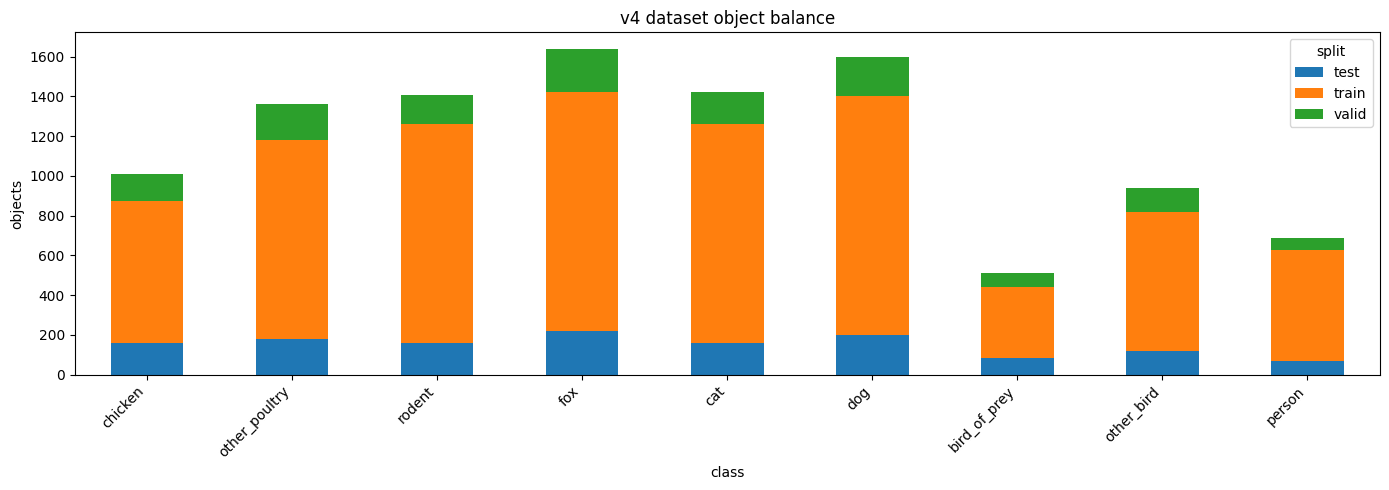

In [7]:
plot_df = summary_df[~summary_df["class"].str.startswith("__")]
pivot = plot_df.pivot(index="class", columns="split", values="objects").fillna(0)
pivot.loc[CANONICAL_NAMES].plot(kind="bar", stacked=True, figsize=(14, 5))
plt.title("v4 dataset object balance")
plt.ylabel("objects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Training configuration

In [8]:
import torch
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

MODEL_WEIGHTS = "yolo11m.pt"
RUN_NAME = "v3_yolo11m_aug_balanced"
EPOCHS = 150
IMG_SIZE = 640
PATIENCE = 30

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

TRAIN_ARGS = dict(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=32,
    patience=PATIENCE,
    project=str(RUNS_ROOT),
    name=RUN_NAME,
    pretrained=True,
    seed=SEED,
    deterministic=False,
    workers=2,
    cache="disk",
    device="0,1" if torch.cuda.device_count() >= 2 else 0 if torch.cuda.is_available() else "cpu",
    amp=True,
    cos_lr=True,
    optimizer="auto",
    lr0=0.003,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    close_mosaic=15,
    # Built-in YOLO augmentations.
    hsv_h=0.015,
    hsv_s=0.65,
    hsv_v=0.35,
    degrees=7.0,
    translate=0.08,
    scale=0.45,
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.75,
    mixup=0.10,
    copy_paste=0.05,
    box=7.5,
    cls=0.5,
    dfl=1.5,
)
TRAIN_ARGS


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4


{'data': '/content/chicken_threat_detector_v4_model/imported_dataset/data.yaml',
 'epochs': 150,
 'imgsz': 640,
 'batch': 32,
 'patience': 30,
 'project': '/content/chicken_threat_detector_v4_model/runs',
 'name': 'v3_yolo11m_aug_balanced',
 'pretrained': True,
 'seed': 42,
 'deterministic': False,
 'workers': 2,
 'cache': 'disk',
 'device': '0,1',
 'amp': True,
 'cos_lr': True,
 'optimizer': 'auto',
 'lr0': 0.003,
 'lrf': 0.01,
 'momentum': 0.937,
 'weight_decay': 0.0005,
 'warmup_epochs': 3.0,
 'warmup_momentum': 0.8,
 'warmup_bias_lr': 0.1,
 'close_mosaic': 15,
 'hsv_h': 0.015,
 'hsv_s': 0.65,
 'hsv_v': 0.35,
 'degrees': 7.0,
 'translate': 0.08,
 'scale': 0.45,
 'shear': 2.0,
 'perspective': 0.0005,
 'fliplr': 0.5,
 'flipud': 0.0,
 'mosaic': 0.75,
 'mixup': 0.1,
 'copy_paste': 0.05,
 'box': 7.5,
 'cls': 0.5,
 'dfl': 1.5}

## Train model

In [9]:
model = YOLO(MODEL_WEIGHTS)
results = model.train(**TRAIN_ARGS)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/chicken_threat_detector_v4_model/imported_dataset/data.yaml, degrees=7.0, deterministic=False, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.65, hsv_v=0.35, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic

AttributeError: 'dict' object has no attribute 'save_dir'

In [34]:
from pathlib import Path

def resolve_yolo_run_dir(results, runs_root: Path, run_name: str) -> Path:
    # Case 1: older/newer Ultralytics object with .save_dir
    save_dir = getattr(results, "save_dir", None)
    if save_dir is not None:
        p = Path(save_dir)
        if p.exists():
            return p

    # Case 2: results is a dict
    if isinstance(results, dict):
        save_dir = results.get("save_dir")
        if save_dir is not None:
            p = Path(save_dir)
            if p.exists():
                return p

    # Case 3: normal expected path from your TRAIN_ARGS
    expected = Path(runs_root) / run_name
    if (expected / "weights").exists():
        return expected

    # Case 4: Ultralytics may auto-increment the run name, e.g. name2, name3
    candidates = sorted(
        Path(runs_root).glob(f"{run_name}*"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    for candidate in candidates:
        if (candidate / "weights" / "best.pt").exists() or (candidate / "weights" / "last.pt").exists():
            return candidate

    raise FileNotFoundError(
        f"No YOLO run directory with weights found under {runs_root} for run name {run_name!r}."
    )


RUN_DIR = resolve_yolo_run_dir(results, RUNS_ROOT, RUN_NAME)

BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = RUN_DIR / "weights" / "last.pt"

print(f"Run directory: {RUN_DIR}")
print(f"Best weights: {BEST_WEIGHTS} | exists={BEST_WEIGHTS.exists()}")
print(f"Last weights: {LAST_WEIGHTS} | exists={LAST_WEIGHTS.exists()}")

if not BEST_WEIGHTS.exists() and LAST_WEIGHTS.exists():
    print("best.pt not found, falling back to last.pt")
    BEST_WEIGHTS = LAST_WEIGHTS

if not BEST_WEIGHTS.exists():
    raise FileNotFoundError("No trained weights found. Training may not have completed or the run folder was not saved.")

Run directory: /content/chicken_threat_detector_v4_model/runs/v3_yolo11m_aug_balanced
Best weights: /content/chicken_threat_detector_v4_model/runs/v3_yolo11m_aug_balanced/weights/best.pt | exists=True
Last weights: /content/chicken_threat_detector_v4_model/runs/v3_yolo11m_aug_balanced/weights/last.pt | exists=True


## Evaluate validation and test performance

In [35]:
def evaluate_split(weights_path: Path, split: str):
    eval_model = YOLO(str(weights_path))
    metrics = eval_model.val(
        data=str(DATA_YAML),
        split=split,
        imgsz=IMG_SIZE,
        project=str(RUNS_ROOT),
        name=f"{RUN_NAME}_eval_{split}",
        plots=True,
        conf=0.001,
        iou=0.6,
    )
    print(f"\n{split.upper()} metrics")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"mAP50:    {metrics.box.map50:.4f}")
    print(f"mAP75:    {metrics.box.map75:.4f}")
    return metrics

if not BEST_WEIGHTS.exists() and LAST_WEIGHTS.exists():
    BEST_WEIGHTS = LAST_WEIGHTS
if not BEST_WEIGHTS.exists():
    raise FileNotFoundError("No trained weights found. Run training first.")

valid_metrics = evaluate_split(BEST_WEIGHTS, "val")
test_metrics = evaluate_split(BEST_WEIGHTS, "test")


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,036,971 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 132.5±61.3 MB/s, size: 530.3 KB)
val: Scanning /content/chicken_threat_detector_v4_model/imported_dataset/valid/labels.cache... 788 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 788/788 300.5Mit/s 0.0s
val: /content/chicken_threat_detector_v4_model/imported_dataset/valid/images/valid_000181_caltech_camera_traps_boxes_caltech_camera_traps_boxes_599d7e26-23d2-11e8-a6a3-ec086b02610b.jpg: corrupt JPEG restored and saved
val: /content/chicken_threat_detector_v4_model/imported_dataset/valid/images/valid_000189_caltech_camera_traps_boxes_caltech_camera_traps_boxes_59500354-23d2-11e8-a6a3-ec086b02610b.jpg: corrupt JPEG restored and saved
val: /content/chicken_threat_detector_v4_model/imported_dataset/valid/images/valid_000190_caltech_camera_traps_boxes_caltech_camera_traps_

Exception in thread Thread-29 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 909, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    return self.transform(
        ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    info.get("keep_rgb", False),
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
Exception in thread Thread-28 (plot_images):
Traceback (most recent call 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 4% ──────────── 2/50 1.0s/it 1.0s<48.2s

Exception in thread Thread-30 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 909, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    return self.transform(
        ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    info.get("keep_rgb", False),
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    fp.flush()
              ^
  File "/usr/local/lib/python3.12/dist-pac

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 3/50 1.3it/s 1.5s<36.7s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 4% ──────────── 2/50 1.5s/it 1.6s<1:14

Exception in thread Thread-36 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 909, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    return self.transform(
        ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    info.get("keep_rgb", False),
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    fp.flush()
              ^
  File "/usr/local/lib/python3.12/dist-pac

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 3/50 1.0it/s 2.1s<46.1s

Exception in thread Thread-38 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 909, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    return self.transform(
        ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    info.get("keep_rgb", False),
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_tile
    fp.flush()
              ^
  File "/usr/local/lib/python3.12/dist-pac

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.3it/s 21.5s0.5ss
                   all        796       1306        0.6       0.55      0.556      0.393
               chicken         34        159      0.756      0.465       0.61      0.433
         other_poultry         27        180      0.699      0.372      0.427      0.295
                rodent        118        160      0.636      0.487      0.498      0.248
                   fox        206        220      0.802      0.905      0.927      0.783
                   cat        124        136      0.461      0.757      0.634      0.388
                   dog        138        190       0.63      0.616      0.618      0.442
          bird_of_prey         80         82      0.774      0.876      0.904      0.718
            other_bird         39        111       0.34      0.321      0.302      0.188
                person         30         68      0.301      0.147

In [36]:
def per_class_map_table(metrics, split_name: str) -> pd.DataFrame:
    names = metrics.names if hasattr(metrics, "names") else {i: name for i, name in enumerate(CANONICAL_NAMES)}
    maps = getattr(metrics.box, "maps", [])
    rows = []
    for i, value in enumerate(maps):
        rows.append({"split": split_name, "class": names.get(i, str(i)) if isinstance(names, dict) else names[i], "mAP50-95": float(value)})
    return pd.DataFrame(rows)

per_class_df = pd.concat([
    per_class_map_table(valid_metrics, "valid"),
    per_class_map_table(test_metrics, "test"),
], ignore_index=True)
display(per_class_df.pivot(index="class", columns="split", values="mAP50-95").loc[CANONICAL_NAMES])


split,test,valid
class,,
chicken,0.432626,0.588457
other_poultry,0.295466,0.322276
rodent,0.247655,0.202931
fox,0.783452,0.730844
cat,0.388402,0.291369
dog,0.442349,0.591642
bird_of_prey,0.717527,0.783261
other_bird,0.187763,0.378458
person,0.038639,0.146164


## Inspect evaluation plots

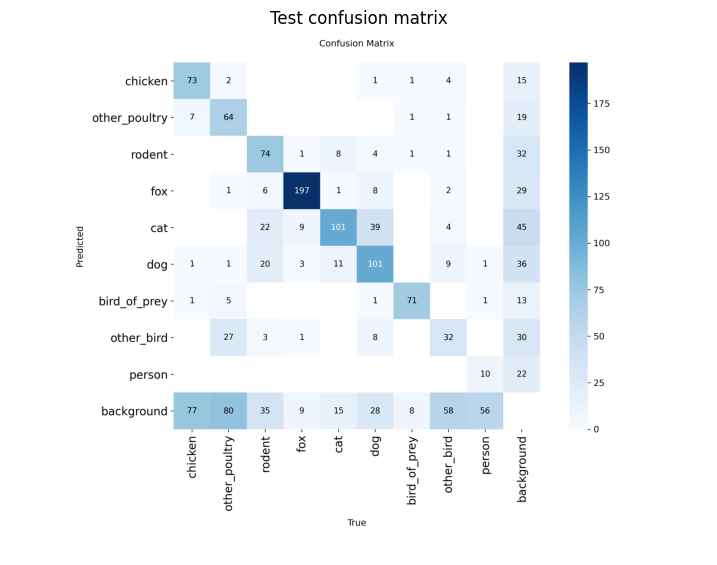

Not found: /content/chicken_threat_detector_v4_model/runs/v3_yolo11m_aug_balanced_eval_test/PR_curve.png


In [38]:
def show_image_if_exists(path: Path, title: str) -> None:
    if path.exists():
        image = Image.open(path)
        plt.figure(figsize=(9, 7))
        plt.imshow(image)
        plt.axis("off")
        plt.title(title)
        plt.show()
    else:
        print(f"Not found: {path}")

show_image_if_exists(RUNS_ROOT / f"{RUN_NAME}_eval_test" / "confusion_matrix.png", "Test confusion matrix")
show_image_if_exists(RUNS_ROOT / f"{RUN_NAME}_eval_test" / "PR_curve.png", "Test PR curve")


## Export best model package

In [28]:
MODEL_EXPORT_DIR = EXPORT_ROOT / RUN_NAME
MODEL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for source in [BEST_WEIGHTS, LAST_WEIGHTS, DATA_YAML, RUN_DIR / "args.yaml", RUN_DIR / "results.csv"]:
    if Path(source).exists():
        shutil.copy2(source, MODEL_EXPORT_DIR / Path(source).name)

# Also save a compact metrics summary.
metrics_summary = {
    "model_weights": MODEL_WEIGHTS,
    "run_name": RUN_NAME,
    "best_weights": str(BEST_WEIGHTS),
    "valid_map50_95": float(valid_metrics.box.map),
    "valid_map50": float(valid_metrics.box.map50),
    "test_map50_95": float(test_metrics.box.map),
    "test_map50": float(test_metrics.box.map50),
    "class_names": CANONICAL_NAMES,
}
(MODEL_EXPORT_DIR / "metrics_summary_v3.yaml").write_text(yaml.safe_dump(metrics_summary, sort_keys=False), encoding="utf-8")

zip_file = Path(shutil.make_archive(str(EXPORT_ROOT / RUN_NAME), "zip", root_dir=MODEL_EXPORT_DIR))
print(f"Model package: {zip_file}")
print(f"Size: {zip_file.stat().st_size / (1024 * 1024):.1f} MB")

if IN_COLAB:
    from google.colab import files
    files.download(str(zip_file))
else:
    print(zip_file)


Model package: /content/chicken_threat_detector_v4_model/exports/v3_yolo11m_aug_balanced.zip
Size: 71.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
from pathlib import Path
import shutil
from IPython.display import FileLink, display

# 1. Search likely locations for your zip
possible_zips = []

search_roots = [
    Path("/content"),
    Path("/kaggle/working"),
    Path.cwd(),
]

for root in search_roots:
    if root.exists():
        possible_zips.extend(root.rglob("*.zip"))

print("Found zip files:")
for z in possible_zips:
    print(" -", z, f"({z.stat().st_size / (1024 * 1024):.1f} MB)")

if not possible_zips:
    raise FileNotFoundError("No zip file found. The archive may not have been created or may be in another folder.")

# 2. Pick the newest/largest likely model zip
zip_file = sorted(possible_zips, key=lambda p: p.stat().st_mtime, reverse=True)[0]

print("\nUsing zip:")
print(zip_file)

# 3. Copy to Kaggle output folder
kaggle_output_dir = Path("/kaggle/working")
kaggle_output_dir.mkdir(parents=True, exist_ok=True)

target_zip = kaggle_output_dir / zip_file.name

if zip_file.resolve() != target_zip.resolve():
    shutil.copy2(zip_file, target_zip)

print("\nCopied to Kaggle output:")
print(target_zip)
print(f"Size: {target_zip.stat().st_size / (1024 * 1024):.1f} MB")

display(FileLink(str(target_zip)))

Found zip files:
 - /content/chicken_threat_detector_v4_model/exports/v3_yolo11m_aug_balanced.zip (71.2 MB)
 - /kaggle/working/v3_yolo11m_aug_balanced.zip (71.2 MB)
 - /kaggle/working/v3_yolo11m_aug_balanced.zip (71.2 MB)

Using zip:
/content/chicken_threat_detector_v4_model/exports/v3_yolo11m_aug_balanced.zip

Copied to Kaggle output:
/kaggle/working/v3_yolo11m_aug_balanced.zip
Size: 71.2 MB


/kaggle/working/v3_yolo11m_aug_balanced.zip

## Inference sanity check on random test images


0: 640x640 1 dog, 31.6ms
1: 640x640 1 cat, 1 dog, 31.6ms
2: 640x640 1 cat, 31.6ms
3: 640x640 1 cat, 31.6ms
4: 640x640 1 cat, 2 other_birds, 31.6ms
5: 640x640 1 fox, 31.6ms
Speed: 2.8ms preprocess, 31.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


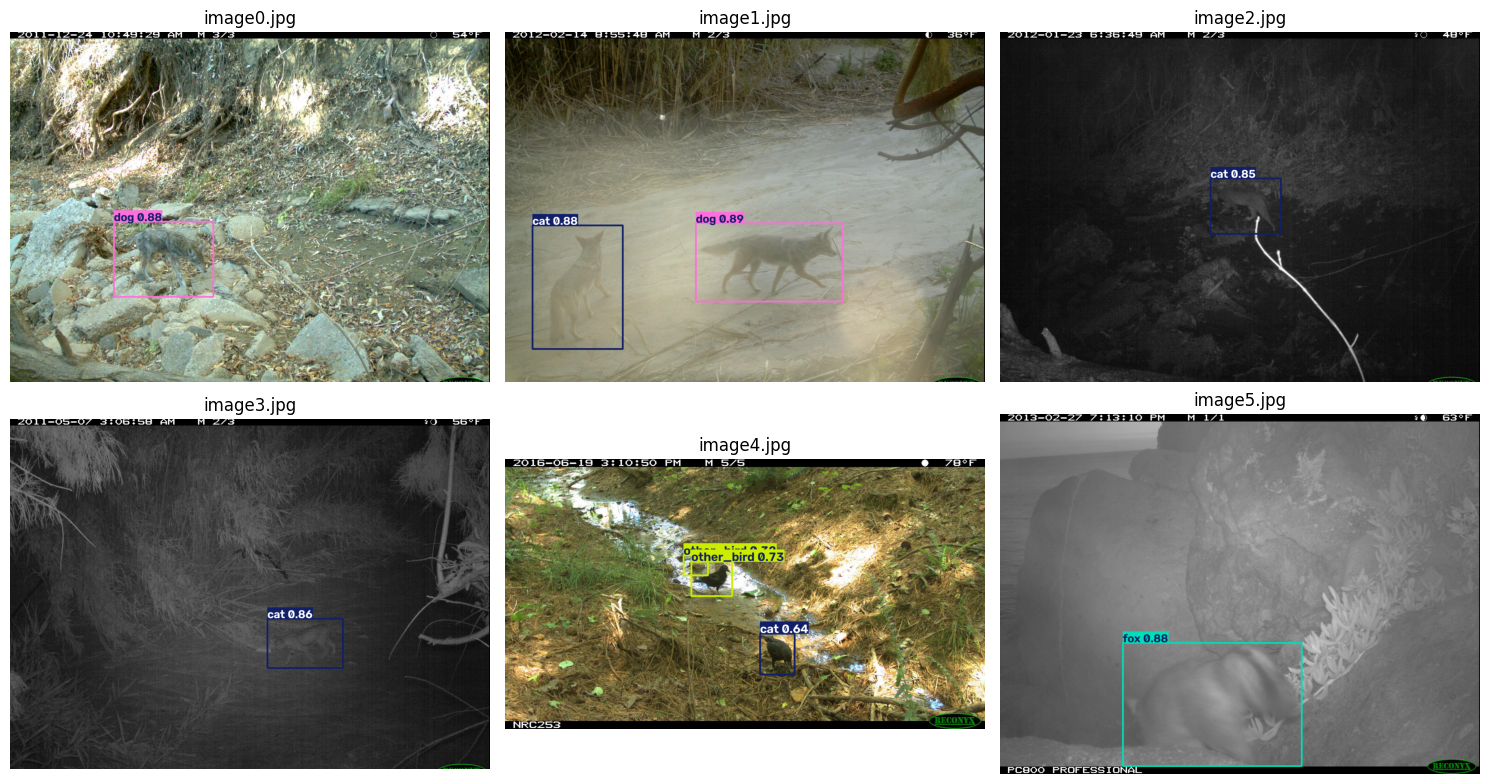

In [32]:
sample_dir = DATASET_ROOT / "test" / "images"
sample_images = image_files(sample_dir)
if not sample_images:
    print("No test images found.")
else:
    selected = random.sample(sample_images, k=min(6, len(sample_images)))
    inference_model = YOLO(str(BEST_WEIGHTS))
    predictions = inference_model.predict(source=[str(path) for path in selected], conf=0.25, imgsz=IMG_SIZE)

    columns = 3
    rows = (len(predictions) + columns - 1) // columns
    plt.figure(figsize=(5 * columns, 4 * rows))
    for index, result in enumerate(predictions, start=1):
        rendered = result.plot()[..., ::-1]
        plt.subplot(rows, columns, index)
        plt.imshow(rendered)
        plt.axis("off")
        plt.title(Path(result.path).name[:35])
    plt.tight_layout()
    plt.show()
